# Cross Dataset kiserlet
- ebben a kiserletben a a legutobb betanitott ket VGG16 halot egymas datasetjein fogom letesztelni es kiertekelni
- ez a kiserlet jo ralatast fog adni, hogy hogyan teljesit a halo ugymond "egymas ellen"

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
 
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
 
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
 
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Modellek betoltese
**A ket betanitott modell kulonbozo forrasbol feltoltve inputkent**

In [21]:
KAGGLE_MODEL_PATH = "/kaggle/input/models/balazsakos/vgg16-crop-clahe-kaggle-dataset/keras/default/1/vgg16_kaggle_best.keras"
COVID_MODEL_PATH  = "/kaggle/input/models/balazsakos/vgg16-crop-clahe-kaggle/keras/default/1/vgg16_covid_radiography_best.keras"

### Datasetek betoltese
1. Kaggle Chest X-Ray dataset (eredeti, train/val/test struktura)
2. COVID-19 Radiography Database (flat struktúra, mi osztjuk fel)


In [31]:
KAGGLE_DATASET_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
KAGGLE_TEST_DIR    = os.path.join(KAGGLE_DATASET_DIR, "test")
 
COVID_DATASET_DIR  = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
COVID_NORMAL_DIR   = os.path.join(COVID_DATASET_DIR, "Normal", "images")
COVID_PNEUMONIA_DIR= os.path.join(COVID_DATASET_DIR, "Viral Pneumonia", "images")

In [23]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
 
OUT_ROOT  = "/kaggle/working"
FIG_DIR   = os.path.join(OUT_ROOT, "figures")
MET_DIR   = os.path.join(OUT_ROOT, "metrics")
 
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MET_DIR, exist_ok=True)

### Preprocess

In [24]:
CROP_TOP    = 0.15
CROP_BOTTOM = 0.90
CROP_LEFT   = 0.05
CROP_RIGHT  = 0.95
 
def crop_clahe(img):
    img_uint8 = np.clip(img, 0, 255).astype('uint8')
    h, w = img_uint8.shape[:2]
    y1, y2 = int(h * CROP_TOP), int(h * CROP_BOTTOM)
    x1, x2 = int(w * CROP_LEFT), int(w * CROP_RIGHT)
    cropped = cv2.resize(img_uint8[y1:y2, x1:x2], (224, 224))
    lab = cv2.cvtColor(cropped, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    cl = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    final_img = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)
    return preprocess_input(final_img.astype('float32'))
 
datagen = ImageDataGenerator(preprocessing_function=crop_clahe)

In [26]:
print("Loading Kaggle model...")
kaggle_model = tf.keras.models.load_model(KAGGLE_MODEL_PATH)
print("Loading COVID Radiography model...")
covid_model  = tf.keras.models.load_model(COVID_MODEL_PATH)
print("Both models loaded.")

Loading Kaggle model...
Loading COVID Radiography model...
Both models loaded.


### Kaggle teszthalmaz

In [29]:
kaggle_test_gen = datagen.flow_from_directory(
    KAGGLE_TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
print("Kaggle test set:", kaggle_test_gen.class_indices)

Found 624 images belonging to 2 classes.
Kaggle test set: {'NORMAL': 0, 'PNEUMONIA': 1}


### Covid Radiography Teszthalmaz
**Ugyanolyan 80/10/10 felosztas mint a 11-es notebookban (ugyanaz a SEED)**

In [32]:
normal_files    = [os.path.join(COVID_NORMAL_DIR, f)    for f in os.listdir(COVID_NORMAL_DIR)    if f.lower().endswith((".png", ".jpg", ".jpeg"))]
pneumonia_files = [os.path.join(COVID_PNEUMONIA_DIR, f) for f in os.listdir(COVID_PNEUMONIA_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
 
df = pd.DataFrame({
    "filepath": normal_files + pneumonia_files,
    "label":    ["NORMAL"] * len(normal_files) + ["PNEUMONIA"] * len(pneumonia_files)
})
 
_, df_temp = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df["label"])
_, df_test_covid = train_test_split(df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["label"])
 
print(f"COVID test set: {len(df_test_covid)} képek")
print(df_test_covid["label"].value_counts())

COVID test set: 1154 képek
label
NORMAL       1020
PNEUMONIA     134
Name: count, dtype: int64


In [33]:
covid_test_gen = datagen.flow_from_dataframe(
    df_test_covid,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
print("COVID test set class indices:", covid_test_gen.class_indices)

Found 1154 validated image filenames belonging to 2 classes.
COVID test set class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


### Kiertekelo fuggveny

In [34]:
def evaluate_model(model, test_gen, model_name, dataset_name, fig_suffix):
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=1).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = test_gen.classes
 
    acc     = accuracy_score(y_true, y_pred)
    cm      = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    report  = classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], output_dict=True)
 
    print(f"\n{'='*60}")
    print(f"Model:   {model_name}")
    print(f"Tested on: {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy:         {acc:.4f}")
    print(f"ROC-AUC:          {roc_auc:.4f}")
    print(f"NORMAL recall:    {report['NORMAL']['recall']:.4f}")
    print(f"PNEUMONIA recall: {report['PNEUMONIA']['recall']:.4f}")
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))
 
    # Confusion matrix
    plt.figure(figsize=(5.5, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix\n{model_name} → {dataset_name}")
    plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
    plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    cm_path = os.path.join(FIG_DIR, f"cm_{fig_suffix}.png")
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()
 
    # ROC görbe
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve\n{model_name} → {dataset_name}")
    plt.legend()
    roc_path = os.path.join(FIG_DIR, f"roc_{fig_suffix}.png")
    plt.savefig(roc_path, dpi=150, bbox_inches="tight")
    plt.show()
 
    return {
        "model":                model_name,
        "tested_on":            dataset_name,
        "accuracy":             float(acc),
        "roc_auc":              float(roc_auc),
        "normal_recall":        float(report["NORMAL"]["recall"]),
        "pneumonia_recall":     float(report["PNEUMONIA"]["recall"]),
        "normal_precision":     float(report["NORMAL"]["precision"]),
        "pneumonia_precision":  float(report["PNEUMONIA"]["precision"]),
        "confusion_matrix":     cm.tolist(),
        "classification_report": report
    }

### Cross-Dataset kiertekeles

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step

Model:   VGG16 (Kaggle)
Tested on: Kaggle Chest X-Ray (saját teszthalmaz)
Accuracy:         0.9167
ROC-AUC:          0.9742
NORMAL recall:    0.8333
PNEUMONIA recall: 0.9667
              precision    recall  f1-score   support

      NORMAL       0.94      0.83      0.88       234
   PNEUMONIA       0.91      0.97      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



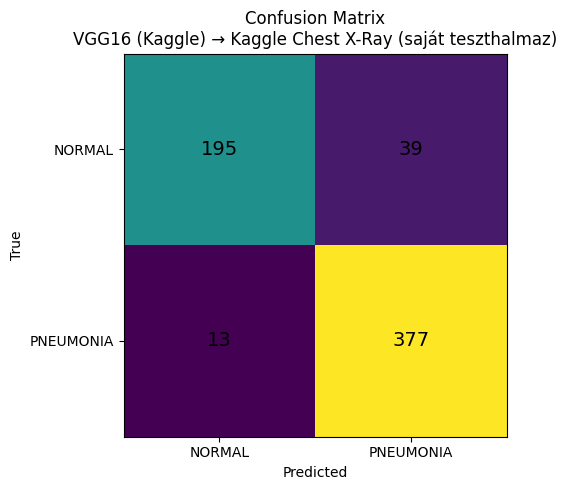

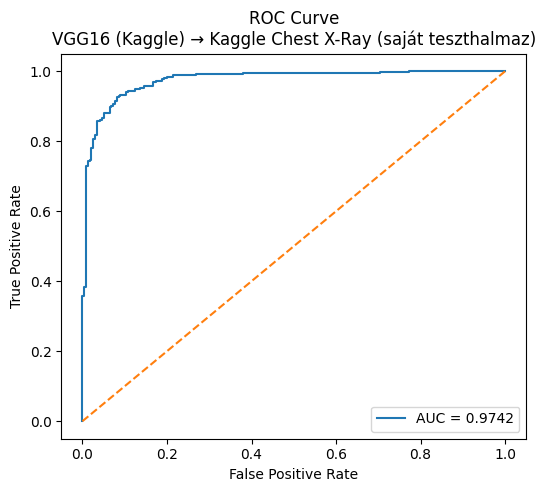

37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step

Model:   VGG16 (Kaggle)
Tested on: COVID-19 Radiography (idegen dataset)
Accuracy:         0.5676
ROC-AUC:          0.8360
NORMAL recall:    0.5176
PNEUMONIA recall: 0.9478
              precision    recall  f1-score   support

      NORMAL       0.99      0.52      0.68      1020
   PNEUMONIA       0.21      0.95      0.34       134

    accuracy                           0.57      1154
   macro avg       0.60      0.73      0.51      1154
weighted avg       0.90      0.57      0.64      1154



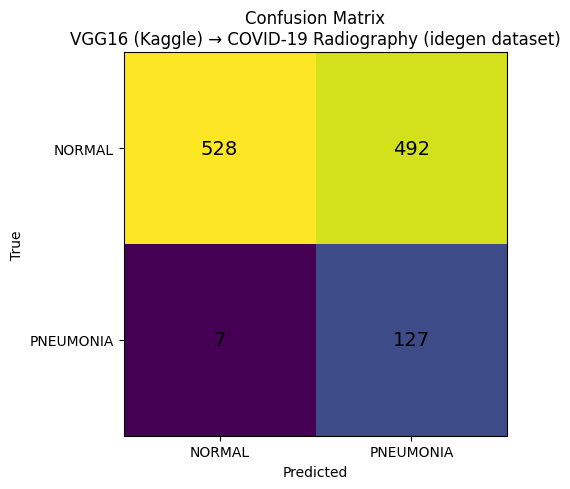

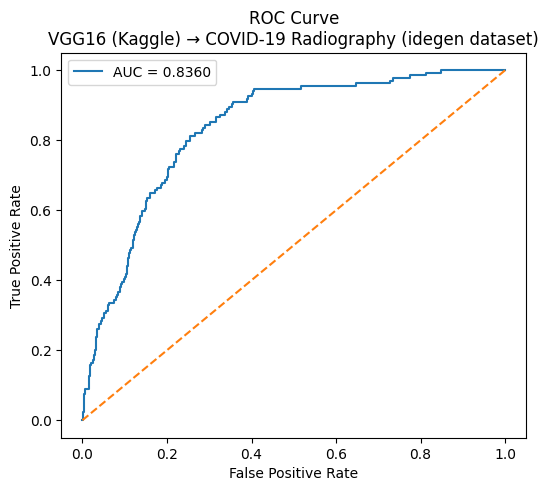

37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step

Model:   VGG16 (COVID Radiography)
Tested on: COVID-19 Radiography (saját teszthalmaz)
Accuracy:         0.9861
ROC-AUC:          0.9987
NORMAL recall:    0.9941
PNEUMONIA recall: 0.9254
              precision    recall  f1-score   support

      NORMAL       0.99      0.99      0.99      1020
   PNEUMONIA       0.95      0.93      0.94       134

    accuracy                           0.99      1154
   macro avg       0.97      0.96      0.97      1154
weighted avg       0.99      0.99      0.99      1154



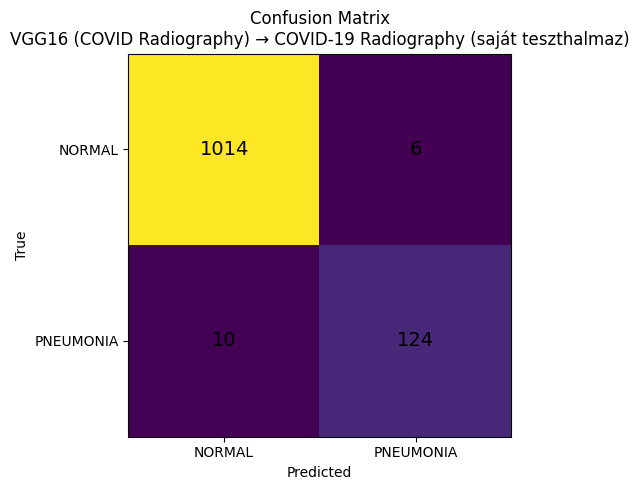

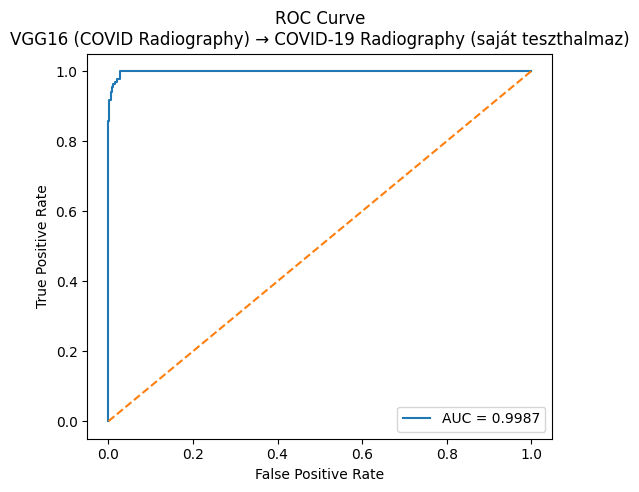

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step

Model:   VGG16 (COVID Radiography)
Tested on: Kaggle Chest X-Ray (idegen dataset)
Accuracy:         0.8429
ROC-AUC:          0.9685
NORMAL recall:    0.5897
PNEUMONIA recall: 0.9949
              precision    recall  f1-score   support

      NORMAL       0.99      0.59      0.74       234
   PNEUMONIA       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



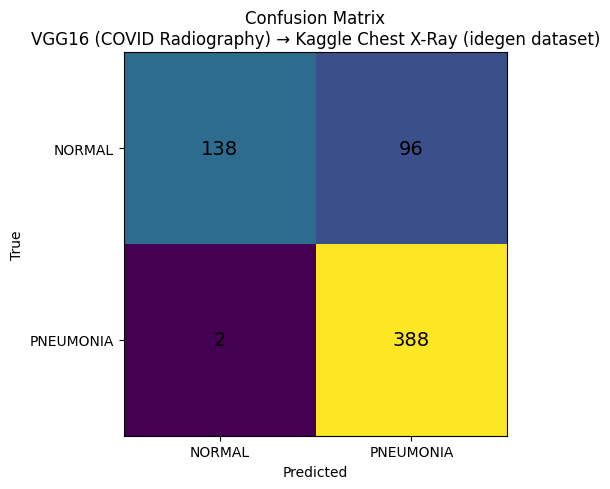

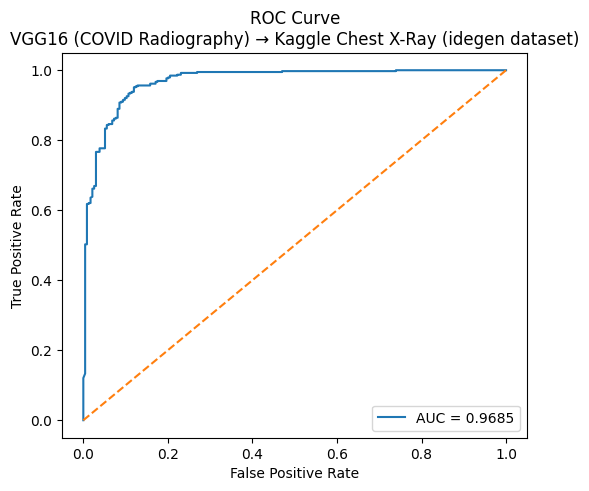

In [36]:
# 1. Kaggle modell → sajat Kaggle teszthalmaz (referencia)
r1 = evaluate_model(
    kaggle_model, kaggle_test_gen,
    model_name="VGG16 (Kaggle)",
    dataset_name="Kaggle Chest X-Ray (saját teszthalmaz)",
    fig_suffix="kaggle_model_on_kaggle"
)
 
# 2. Kaggle modell → COVID Radiography teszthalmaz (cross-dataset)
r2 = evaluate_model(
    kaggle_model, covid_test_gen,
    model_name="VGG16 (Kaggle)",
    dataset_name="COVID-19 Radiography (idegen dataset)",
    fig_suffix="kaggle_model_on_covid"
)
 
# 3. COVID modell → sajat COVID Radiography teszthalmaz (referencia)
r3 = evaluate_model(
    covid_model, covid_test_gen,
    model_name="VGG16 (COVID Radiography)",
    dataset_name="COVID-19 Radiography (saját teszthalmaz)",
    fig_suffix="covid_model_on_covid"
)
 
# 4. COVID modell → Kaggle teszthalmaz (cross-dataset)
r4 = evaluate_model(
    covid_model, kaggle_test_gen,
    model_name="VGG16 (COVID Radiography)",
    dataset_name="Kaggle Chest X-Ray (idegen dataset)",
    fig_suffix="covid_model_on_kaggle"
)

### Osszefoglalo tablazat

In [37]:
results = [r1, r2, r3, r4]
 
print("\n" + "="*80)
print("CROSS-DATASET EVALUATION SUMMARY")
print("="*80)
print(f"{'Model':<30} {'Tested on':<35} {'Acc':>7} {'AUC':>7} {'NRM Rec':>8} {'PNE Rec':>8}")
print("-"*80)
for r in results:
    print(f"{r['model']:<30} {r['tested_on']:<35} {r['accuracy']:>7.4f} {r['roc_auc']:>7.4f} {r['normal_recall']:>8.4f} {r['pneumonia_recall']:>8.4f}")


CROSS-DATASET EVALUATION SUMMARY
Model                          Tested on                               Acc     AUC  NRM Rec  PNE Rec
--------------------------------------------------------------------------------
VGG16 (Kaggle)                 Kaggle Chest X-Ray (saját teszthalmaz)  0.9167  0.9742   0.8333   0.9667
VGG16 (Kaggle)                 COVID-19 Radiography (idegen dataset)  0.5676  0.8360   0.5176   0.9478
VGG16 (COVID Radiography)      COVID-19 Radiography (saját teszthalmaz)  0.9861  0.9987   0.9941   0.9254
VGG16 (COVID Radiography)      Kaggle Chest X-Ray (idegen dataset)  0.8429  0.9685   0.5897   0.9949


### Osszefoglalo grafikon

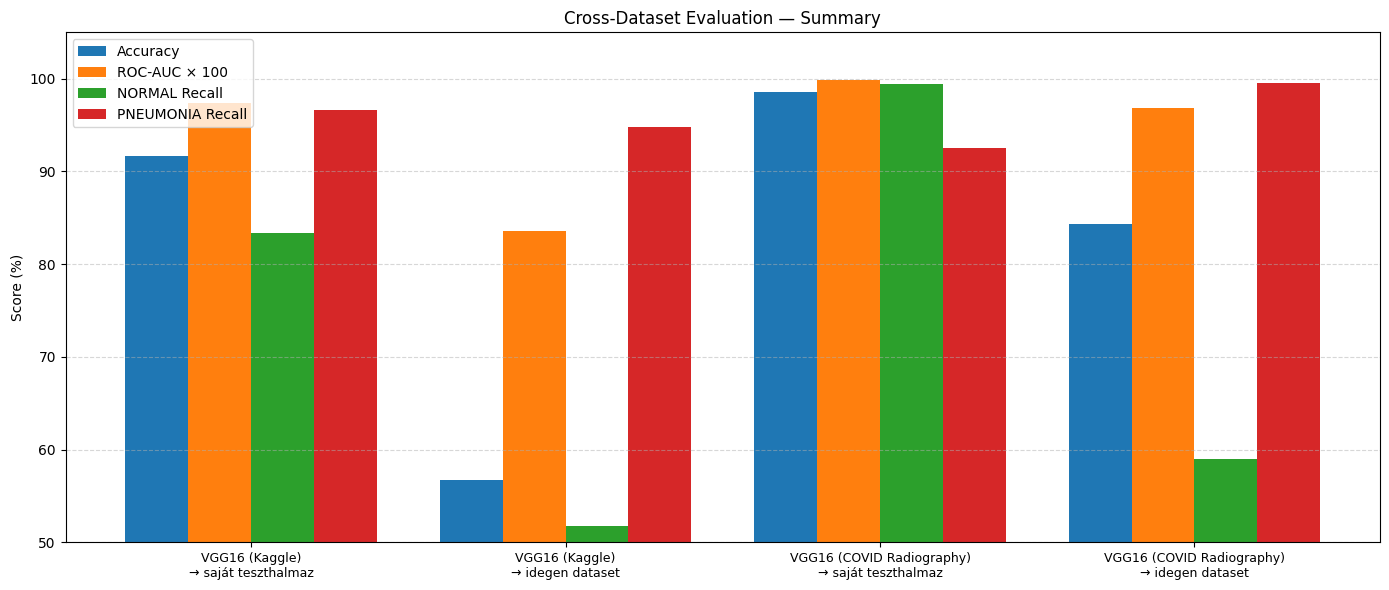

Saved: /kaggle/working/figures/cross_dataset_summary.png


In [38]:
labels    = [f"{r['model']}\n→ {r['tested_on'].split('(')[1].replace(')', '')}" for r in results]
acc_vals  = [r["accuracy"] * 100 for r in results]
auc_vals  = [r["roc_auc"] * 100 for r in results]
nrm_vals  = [r["normal_recall"] * 100 for r in results]
pne_vals  = [r["pneumonia_recall"] * 100 for r in results]
 
x = np.arange(len(labels))
width = 0.2
 
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, acc_vals, width, label="Accuracy")
ax.bar(x - 0.5*width, auc_vals, width, label="ROC-AUC × 100")
ax.bar(x + 0.5*width, nrm_vals, width, label="NORMAL Recall")
ax.bar(x + 1.5*width, pne_vals, width, label="PNEUMONIA Recall")
 
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(50, 105)
ax.set_ylabel("Score (%)")
ax.set_title("Cross-Dataset Evaluation — Summary")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
summary_path = os.path.join(FIG_DIR, "cross_dataset_summary.png")
plt.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", summary_path)

### Mentes JSON-ba

In [39]:
met_path = os.path.join(MET_DIR, "cross_dataset_evaluation.json")
with open(met_path, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", met_path)

Saved: /kaggle/working/metrics/cross_dataset_evaluation.json
